# Day 12 : Hyperprameter Tuning, Model Pipelines & Sliding Window Mastery

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('train.csv')

## Question 1 - Baseline Pipeline

In [2]:
X = df[['Pclass','Age','Fare','SibSp','Parch']].copy()
y = df['Survived'].copy()

X['Median_Age'] = X.groupby('Pclass')['Age'].transform('median')
X['Age'].fillna(X['Median_Age'], inplace=True)
#print(X.isna().sum())
X.drop(columns=['Median_Age'], inplace=True)

X['FamilySize'] = X['SibSp'] + X['Parch'] +1
X['IsAlone'] = [1 if X['FamilySize'][i] == 1 else 0 for i in range(len(X))] 

X.drop(columns=['SibSp','Parch'], inplace=True)

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(712, 5)
(179, 5)


In [ ]:
# Had to google all this lmao

pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),  ## scaler before rnadom forest classifier is unnecessary
    ('classifier', RandomForestClassifier(n_estimators=100,random_state=42))
])

pipeline.fit(X_train,y_train)
base_pred = pipeline.predict(X_test)
accuracy = pipeline.score(X_test,y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7542


1. Pipelines help by arranging all the necessary moving parts of a ML model into a single chronological pipeline which automates the whole ML workflow.
2. It prevents manual errors and ensures consistency across datasets and drastically speeds up model deployment.

## Question 2 - Hyperparameter Tuning

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [5,100,200],
    'max_depth': [3,5,None],
    'min_samples_split': [2,5,10]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(),param_grid=param_grid,cv=5, scoring='accuracy')

grid_search.fit(X_train,y_train)

best_params = grid_search.best_params_
best_cv = grid_search.best_score_

print(best_params)
print(best_cv)


{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
0.7260317147641091


## Question 3 - Best Model

In [9]:
best_pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'],min_samples_split=best_params['min_samples_split']))
])

best_pipeline.fit(X_train,y_train)
best_pred = best_pipeline.predict(X_test)

best_acc = accuracy_score(np.array(y_test),best_pred)
best_precision = precision_score(np.array(y_test),best_pred)
best_recall = recall_score(np.array(y_test),best_pred)
best_f1 = f1_score(np.array(y_test),best_pred)

result_df = pd.DataFrame({
    'Metrics':['Acc','Precision','Recall','F1'],
    'Values':[best_acc,best_precision,best_recall,best_f1]
})

result_df

,Metrics,Values
0,Acc,0.737430
1,Precision,0.775510
2,Recall,0.513514
3,F1,0.617886


It actually decreased the overall average score of the model as compared Day 10

## Question 4 - Feature Importance

In [12]:
model = best_pipeline.named_steps['classifier']
importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Features': X.columns,
    'Importance': importance
})
feature_importance_df.sort_values(by='Importance',ascending=False,inplace=True)
feature_importance_df

,Features,Importance
2,Fare,0.381573
0,Pclass,0.305750
3,FamilySize,0.136922
1,Age,0.136095
4,IsAlone,0.039660


Tuning just increased the importance of FamilySize over Age, the rest seem to be the same.

## Question 5 - Classification Report

In [14]:
from sklearn.metrics import classification_report

class_report = classification_report(np.array(y_test),best_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.72      0.90      0.80       105
           1       0.78      0.51      0.62        74

    accuracy                           0.74       179
   macro avg       0.75      0.70      0.71       179
weighted avg       0.74      0.74      0.72       179



It gives class wise scores for each metric along with macro and weighted averages.
Weighted avg is an important metrics in this case as it tells us the avg output even if there is a class imbalance.

## Question 6 - Confusion Matrix Visualization

[[94 11]
 [36 38]]


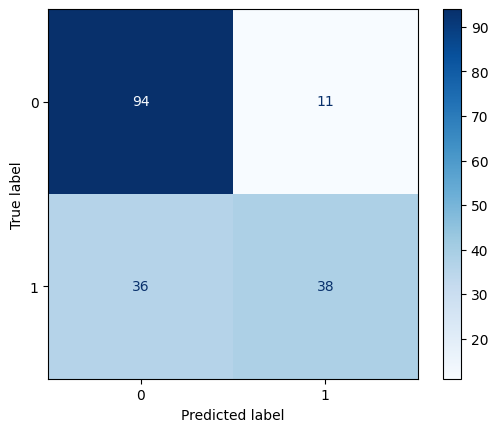

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(np.array(y_test), best_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['0','1'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Question 7 - Business Scenario

We would optimize for Recall as that tell us the proportion of actual positive instances that the model successfully found. Measures the quantity.

## Question 8 - Quant Scenario

First I would need to look at the cv of the prediction, check what is the amount of false positives in the 54%.
Since 54% is just a little over a coin toss, i would have to have strict stop losses in place to mitigate any risks in this scenario. I would also look at the average volatility of BTC on that day to see what the highs and lows of the day are.
I would have to price my trade by taking into consideration all the transaction costs.
For further hedging, I could possibly use Delta or Gamma hedging methods and sell call options depending on the number of BTC im buying.

## Question 9 - Data Leak Challenge

A. Because this would introduce look ahead bias and if we already know tomorrows price the model will start overfitting completely.

C. Hyperparameter tuning should be done using the train set so that it trains the model with the required params to then predict unseen data. If you already show the model the unseen data then it will ofcourse predict it with ease.

## Question 10 - Model Selection

Honestly my answer to match all 3 criteria is Logistic Regression. It is fast executing as it only looks at linear relationships and thus does not go into complex computations, it is the most explainable of the 3 as random forest has a cluster of trees and so does gradient boosting.
Easy deployment could be done for all 3 but since the train time for the latter 2 are increasingly higher, Logistic Regression would win in this scenario.

## Bonus ML

1. 500 features could introduce alot of noise and unimportant features which would either decrease accuracy or increase execution time.
2. PCA, Recursive Feature Elimination, Correlation
3. It would filter all the important features from the unimportant ones and give us a better cleaner model without any noise, decrease execution time which is key in quant models as well as improve accuracy.

---

## DSA Challenge #9

In [37]:
nums = [1,12,-5,-6,50,3]
k=4
max_len = len(nums)
window = nums[:k]
max_avg = 0

for i in range(max_len-k):
    max_avg = max(sum(window)/k,max_avg)
    window.remove(window[0])
    window.append(nums[i+k])

print(max_avg)

## Correction 

window_sum = sum(nums[:k])

for i in range(k,len(nums)):
    window_sum += nums[i]
    window_sum -= nums[i-k]
    max_avg = max(max_avg,window_sum/k)
print(max_avg)

12.75
12.75


1. O(n^2)
2. O(n+k)
3. Oh lol i recalculated it every time

## DSA Challenge #10

In [38]:
# This is the Longest Repeating Character Replacement problem from Leetcode. I will try to solve it using the sliding window technique.
s = "AABABBA"
k = 1
max_len = len(s)
window = list(s[:k])
print(window)

# for i in range(len(s[k:])):
#     window.append(s[i])
    
## Correction
def characterReplacement(s: str, k: int) -> int:
    left = 0
    max_len=0
    freq = {}
    max_freq = 0

    for right in range(len(s)):
        freq[s[right]] = freq.get(s[right],0)+1
        max_freq = max(max_freq,freq[s[right]])
        while (right-left+1) - max_freq > k:
            freq[s[left]] -= 1
            left += 1
        max_len = max(max_len, right-left+1)
    return max_len

print(characterReplacement("AABABBA",1))


['A']
4


Damn bruh i give up, i dont know how to do this or what i even have to do in this question :')